## Load HuggingFace datasets

In [1]:
from datasets import load_dataset

# Load dataset 1
ds1 = load_dataset("cnamuangtoun/resume-job-description-fit")
print(ds1)

ds2 = load_dataset("AzharAli05/Resume-Screening-Dataset")
print(ds2)

train.csv:   0%|          | 0.00/53.4M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1759 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['resume_text', 'job_description_text', 'label'],
        num_rows: 6241
    })
    test: Dataset({
        features: ['resume_text', 'job_description_text', 'label'],
        num_rows: 1759
    })
})


README.md:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

dataset.csv:   0%|          | 0.00/34.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10174 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Role', 'Resume', 'Decision', 'Reason_for_decision', 'Job_Description'],
        num_rows: 10174
    })
})


## Convert to Pandas and Label plot

Train set shape: (6241, 3)
Test set shape: (1759, 3)

Label distribution in Train Set:
label
No Fit           3143
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64


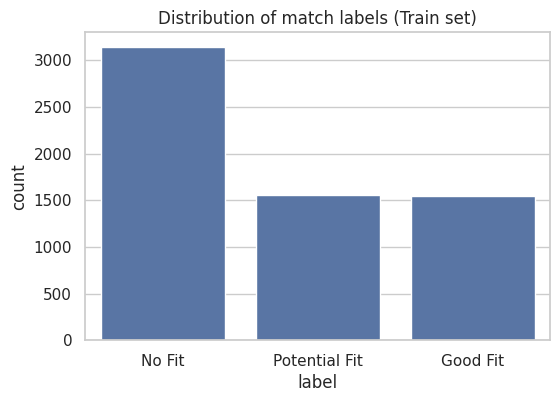

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#set plot style
sns.set_theme(style="whitegrid")

# convert huggingface dataset to pandas dataframe
df_train = ds1['train'].to_pandas()
df_test = ds1['test'].to_pandas()

print(f"Train set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

# check the distribution of labels
print("\nLabel distribution in Train Set:")
print(df_train['label'].value_counts(dropna=False))

# plot the distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df_train, x='label')
plt.title("Distribution of match labels (Train set)")
plt.show()

## Basic word count histograms

Resume Word count stats: 
count    6241.000000
mean      708.056722
std       391.724444
min        84.000000
50%       618.000000
75%       810.000000
90%      1153.000000
95%      1591.000000
max      3134.000000
Name: resume_word_count, dtype: float64

Job Description word count stats: 
count    6241.000000
mean      371.546387
std       239.142971
min        11.000000
50%       328.000000
75%       532.000000
90%       695.000000
95%       810.000000
max      1079.000000
Name: jd_word_count, dtype: float64


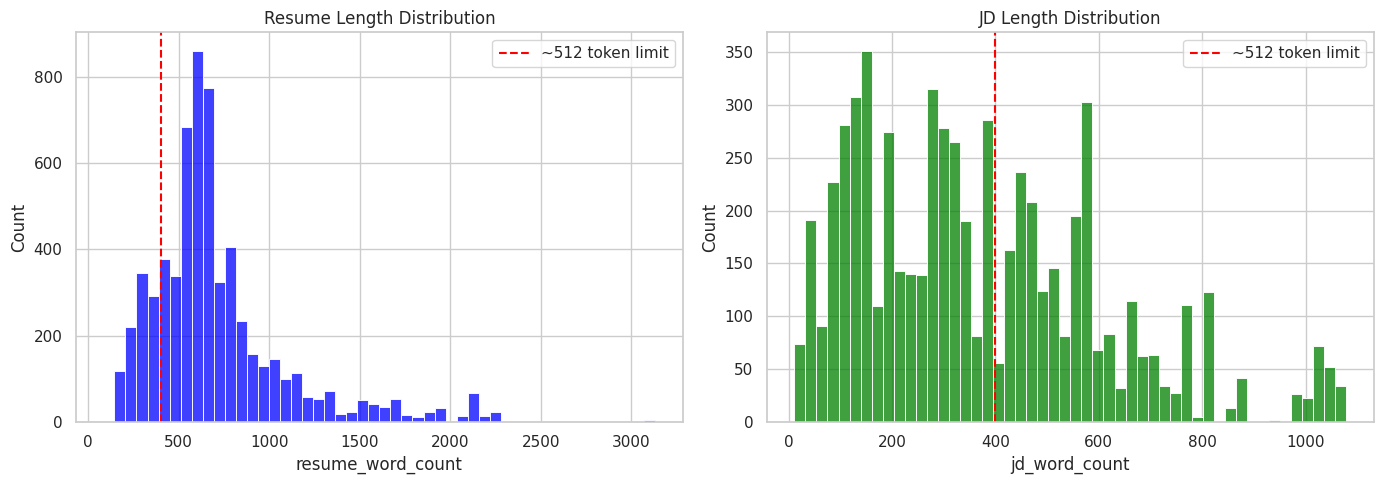

In [3]:
# Calculate the approximate word counts (splitting by whitespace is a good proxy for tokens)
df_train['resume_word_count'] = df_train['resume_text'].apply(lambda x: len(str(x).split()))
df_train['jd_word_count'] = df_train['job_description_text'].apply(lambda x:len(str(x).split()))

# Print summary stats
print("Resume Word count stats: ")
print(df_train['resume_word_count'].describe(percentiles=[0.50,0.75,0.90,0.95]))

print("\nJob Description word count stats: ")
print(df_train['jd_word_count'].describe(percentiles=[0.50,0.75,0.90,0.95]))

# Plot the distributions
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df_train['resume_word_count'],bins = 50, ax = ax[0],color='blue')
ax[0].set_title('Resume Length Distribution')
ax[0].axvline(400, color='red',linestyle='--',label='~512 token limit')
ax[0].legend()

sns.histplot(df_train['jd_word_count'],bins = 50, ax = ax[1], color='green')
ax[1].set_title('JD Length Distribution')
ax[1].axvline(400,color='red',linestyle='--',label = '~512 token limit')
ax[1].legend()

plt.tight_layout()
plt.show()

**Hypothesis:** Transformer models (like RoBERTa) have a strict 512-token limit (roughly 350-400 words). Looking at the JD length distribution above, many Job Descriptions exceed this. What if the actual "Requirements" or "Technical Skills" don't appear until *after* the 400th word? If so, the model will just read company marketing boilerplate and fail to see the technical requirements due to truncation. Let's look at the data to prove this.

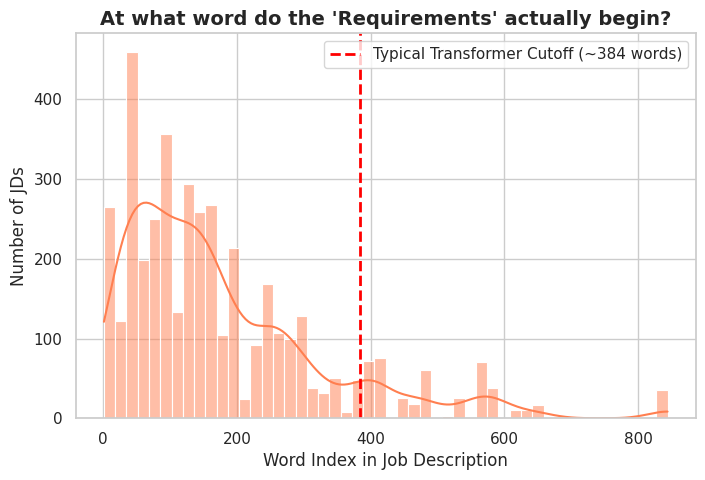

Data Insight: 462 JDs hid requirements AFTER the Transformer cutoff!
Action Taken: Created 'smart_jd_text' to bring requirements to the front.


In [4]:
# 1. Find where the requirements start
def find_requirements_start_word(text):
    if not isinstance(text, str): return 0
    text_lower = text.lower()
    
    idx = text_lower.find('requirements')
    if idx == -1: idx = text_lower.find('qualifications')
    if idx == -1: idx = text_lower.find('what you need')
    
    if idx != -1: return len(text[:idx].split())
    return 0 

df_train['req_start_word_idx'] = df_train['job_description_text'].apply(find_requirements_start_word)
valid_starts = df_train[df_train['req_start_word_idx'] > 0]['req_start_word_idx']

plt.figure(figsize=(8, 5))
sns.histplot(valid_starts, bins=50, color='coral', kde=True)
plt.axvline(384, color='red', linestyle='--', linewidth=2, label='Typical Transformer Cutoff (~384 words)')
plt.title("At what word do the 'Requirements' actually begin?", fontsize=14, fontweight='bold')
plt.xlabel("Word Index in Job Description")
plt.ylabel("Number of JDs")
plt.legend()
plt.show()

# 2. Implement the Fix (Smart Parsing)
def smart_parse_jd(text, max_words=350):
    if not isinstance(text, str): return ""
    text_lower = text.lower()
    target_sections = ['requirements', 'qualifications', 'what you need', 'what you bring', 'skills']
    
    start_idx = 0
    for section in target_sections:
        idx = text_lower.find(section)
        if idx != -1:
            start_idx = idx
            break
            
    extracted_text = text[start_idx:]
    return " ".join(extracted_text.split()[:max_words])

# Apply to datasets
df_train['smart_jd_text'] = df_train['job_description_text'].apply(smart_parse_jd)
df_test['smart_jd_text'] = df_test['job_description_text'].apply(smart_parse_jd)

print(f"Data Insight: {len(valid_starts[valid_starts > 384])} JDs hid requirements AFTER the Transformer cutoff!")
print("Action Taken: Created 'smart_jd_text' to bring requirements to the front.")

## Backup dataset

In [5]:
# Convert ds2 to Pandas
df_backup = ds2['train'].to_pandas()

print("Backup Dataset Info:")
print(df_backup.info())

print("\nFirst 3 rows:")
display(df_backup.head(3))

# If there is a category/label column, let's see it
if 'Category' in df_backup.columns or 'label' in df_backup.columns:
    target_col = 'Category' if 'Category' in df_backup.columns else 'label'
    print(f"\nDistribution of {target_col}:")
    print(df_backup[target_col].value_counts().head(10))

Backup Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10174 entries, 0 to 10173
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Role                 10174 non-null  object
 1   Resume               10174 non-null  object
 2   Decision             10174 non-null  object
 3   Reason_for_decision  10174 non-null  object
 4   Job_Description      10174 non-null  object
dtypes: object(5)
memory usage: 397.6+ KB
None

First 3 rows:


,Role,Resume,Decision,Reason_for_decision,Job_Description
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,Game Developer,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...


## Map Numeric scores

In [6]:
# Map text labels to match numerical scores
label_mapping = {
    'No Fit': 0.0,
    'Potential Fit': 0.5,
    'Good Fit': 1.0
}

df_train['score'] = df_train['label'].map(label_mapping)
df_test['score'] = df_test['label'].map(label_mapping)

print("Numeric score mapping:")
print(df_train['score'].value_counts(dropna=False))

Numeric score mapping:
score
0.0    3143
0.5    1556
1.0    1542
Name: count, dtype: int64


## Load linkedin skills

In [7]:
skills_path = '/kaggle/input/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024/job_skills.csv' 
df_skills = pd.read_csv(skills_path)

## Extract top skills library

In [8]:
# Drop missing values and take a sample for speed
df_skills_clean = df_skills.dropna(subset=['job_skills']).copy()
sample_skills = df_skills_clean['job_skills'].head(100000)

# Split by comma and clean
individual_skills = sample_skills.str.split(',').explode()
individual_skills = individual_skills.astype(str).str.lower().str.strip()

# Filter noise
individual_skills = individual_skills[individual_skills.str.len() > 1]
individual_skills = individual_skills[individual_skills.str.len() < 40]
noise_phrases = ["this context does not mention", "none found"]
individual_skills = individual_skills[~individual_skills.str.contains('|'.join(noise_phrases))]

top_individual_skills = individual_skills.value_counts()
print(f"Total True UNIQUE skills in sample: {len(top_individual_skills)}")

Total True UNIQUE skills in sample: 376422


**Data Engineering Evolution:** Initially, I removed stopwords and used simple Regex to find skills. However, Transformers rely on stopwords (like 'not', 'and') for context. Furthermore, looping 500 Regex statements per resume is extremely slow, limiting our graph size.
**Solution:** I implemented a *Dual-Pipeline*. The raw text goes to the Transformer. For Graph extraction, I clean the text heavily and use `FlashText`, an $O(N)$ algorithm that allows us to expand our vocabulary from 500 to 2,500 skills effortlessly.

## Dual Pipeline

In [9]:
!pip install flashtext

  Preparing metadata (setup.py) ... done
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9300 sha256=aa9dabe81e6dd635841e82dccc6c8976e887d9d9eca6ef9f3742f5a09a90d786
  Stored in directory: /root/.cache/pip/wheels/8c/24/da/4d994d7a27cfc73a4e513a669fbeec4a71f871fe245a81977f
Successfully built flashtext


Extracting Skills with FlashText...


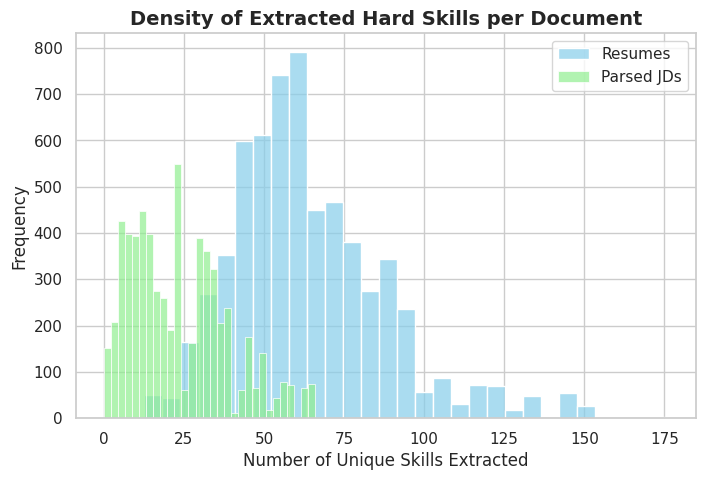

In [10]:
import re
from flashtext import KeywordProcessor

# 1. Clean text ONLY for the graph (keep natural text for Transformers)
def clean_for_graph(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s\+]', ' ', text) # Keep '+' for c++
    return re.sub(r'\s+', ' ', text).strip()

df_train['graph_res_text'] = df_train['resume_text'].apply(clean_for_graph)
df_train['graph_jd_text'] = df_train['smart_jd_text'].apply(clean_for_graph)
df_test['graph_res_text'] = df_test['resume_text'].apply(clean_for_graph)
df_test['graph_jd_text'] = df_test['smart_jd_text'].apply(clean_for_graph)

# 2. Expand vocabulary to top 2500 skills!
expanded_vocab = list(top_individual_skills.head(2500).index)

# 3. Setup FlashText Processor
kp = KeywordProcessor(case_sensitive=False)
for skill in expanded_vocab:
    kp.add_keyword(skill)

# 4. Extract skills into Lists
print("Extracting Skills with FlashText...")
df_train['extracted_skills_res'] = df_train['graph_res_text'].apply(lambda x: list(set(kp.extract_keywords(x))))
df_train['extracted_skills_jd'] = df_train['graph_jd_text'].apply(lambda x: list(set(kp.extract_keywords(x))))

df_test['extracted_skills_res'] = df_test['graph_res_text'].apply(lambda x: list(set(kp.extract_keywords(x))))
df_test['extracted_skills_jd'] = df_test['graph_jd_text'].apply(lambda x: list(set(kp.extract_keywords(x))))

df_train['skill_count_res'] = df_train['extracted_skills_res'].apply(len)
df_train['skill_count_jd'] = df_train['extracted_skills_jd'].apply(len)

# 5. Plot the result to show how dense the extracted graphs will be
plt.figure(figsize=(8,5))
sns.histplot(df_train['skill_count_res'], bins=30, color='skyblue', label='Resumes', alpha=0.7)
sns.histplot(df_train['skill_count_jd'], bins=30, color='lightgreen', label='Parsed JDs', alpha=0.7)
plt.title("Density of Extracted Hard Skills per Document", fontsize=14, fontweight='bold')
plt.xlabel("Number of Unique Skills Extracted")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Build Graph edges using extended vocabulary

In [11]:
from itertools import combinations
from collections import Counter

vocab_set = set(expanded_vocab)
co_occurrences = Counter()

print("Building Graph Edges from LinkedIn Data...")
for skill_string in sample_skills.head(50000): 
    skills_in_job = [s.strip().lower() for s in str(skill_string).split(',')]
    valid_skills = [s for s in skills_in_job if s in vocab_set]
    
    for pair in combinations(valid_skills, 2):
        pair = tuple(sorted(pair))
        co_occurrences[pair] += 1

print(f"Total unique connections (edges): {len(co_occurrences)}")

print("\nTop 10 Strongest Skill Connections:")
for pair, count in co_occurrences.most_common(10):
    print(f"{pair[0]} <---> {pair[1]}: Weight = {count}")

Building Graph Edges from LinkedIn Data...
Total unique connections (edges): 644571

Top 10 Strongest Skill Connections:
communication <---> customer service: Weight = 5875
communication <---> teamwork: Weight = 5525
customer service <---> teamwork: Weight = 4132
communication <---> problem solving: Weight = 3826
communication <---> problemsolving: Weight = 3465
communication <---> time management: Weight = 3351
attention to detail <---> communication: Weight = 3243
communication <---> leadership: Weight = 3138
attention to detail <---> teamwork: Weight = 2980
attention to detail <---> customer service: Weight = 2710


In [12]:
import json

# Save DataFrames
df_train.to_csv('/kaggle/working/train_clean.csv', index=False)
df_test.to_csv('/kaggle/working/test_clean.csv', index=False)

# Save the 2500 skill dictionary
with open('/kaggle/working/skill_vocab.json', 'w') as f:
    json.dump(expanded_vocab, f)

# Save Graph Edges
edges_to_save = [{"source": pair[0], "target": pair[1], "weight": weight} 
                 for pair, weight in co_occurrences.items()]
                 
with open('/kaggle/working/graph_edges.json', 'w') as f:
    json.dump(edges_to_save, f)

print("All data artifacts saved successfully to /kaggle/working/!")

All data artifacts saved successfully to /kaggle/working/!
